In [ ]:
# Step 1 – install sklearn if needed (usually pre-installed in Colab)
!pip install scikit-learn -q

In [ ]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib import rcParams
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, accuracy_score
from numpy.polynomial import polynomial as P

df = pd.read_csv("global_water_consumption_2000_2025.csv")

print("First 5 rows:")
print(df.head())

print("\nLast 5 rows:")
print(df.tail())

First 5 rows:
  Country  Year  Total Water Consumption (Billion m3)  \
0   China  2000                                586.04   
1   China  2001                                590.09   
2   China  2002                                600.00   
3   China  2003                                610.45   
4   China  2004                                617.08   

   Per Capita Water Use (L/Day)  Agricultural Water Use (%)  \
0                         146.6                        63.8   
1                         161.4                        63.7   
2                         150.2                        63.6   
3                         162.5                        63.5   
4                         148.7                        63.4   

   Industrial Water Use (%)  Household Water Use (%)  Rainfall Impact (mm)  \
0                      23.1                     13.1                 633.8   
1                      23.2                     13.2                 854.9   
2                      23.2   

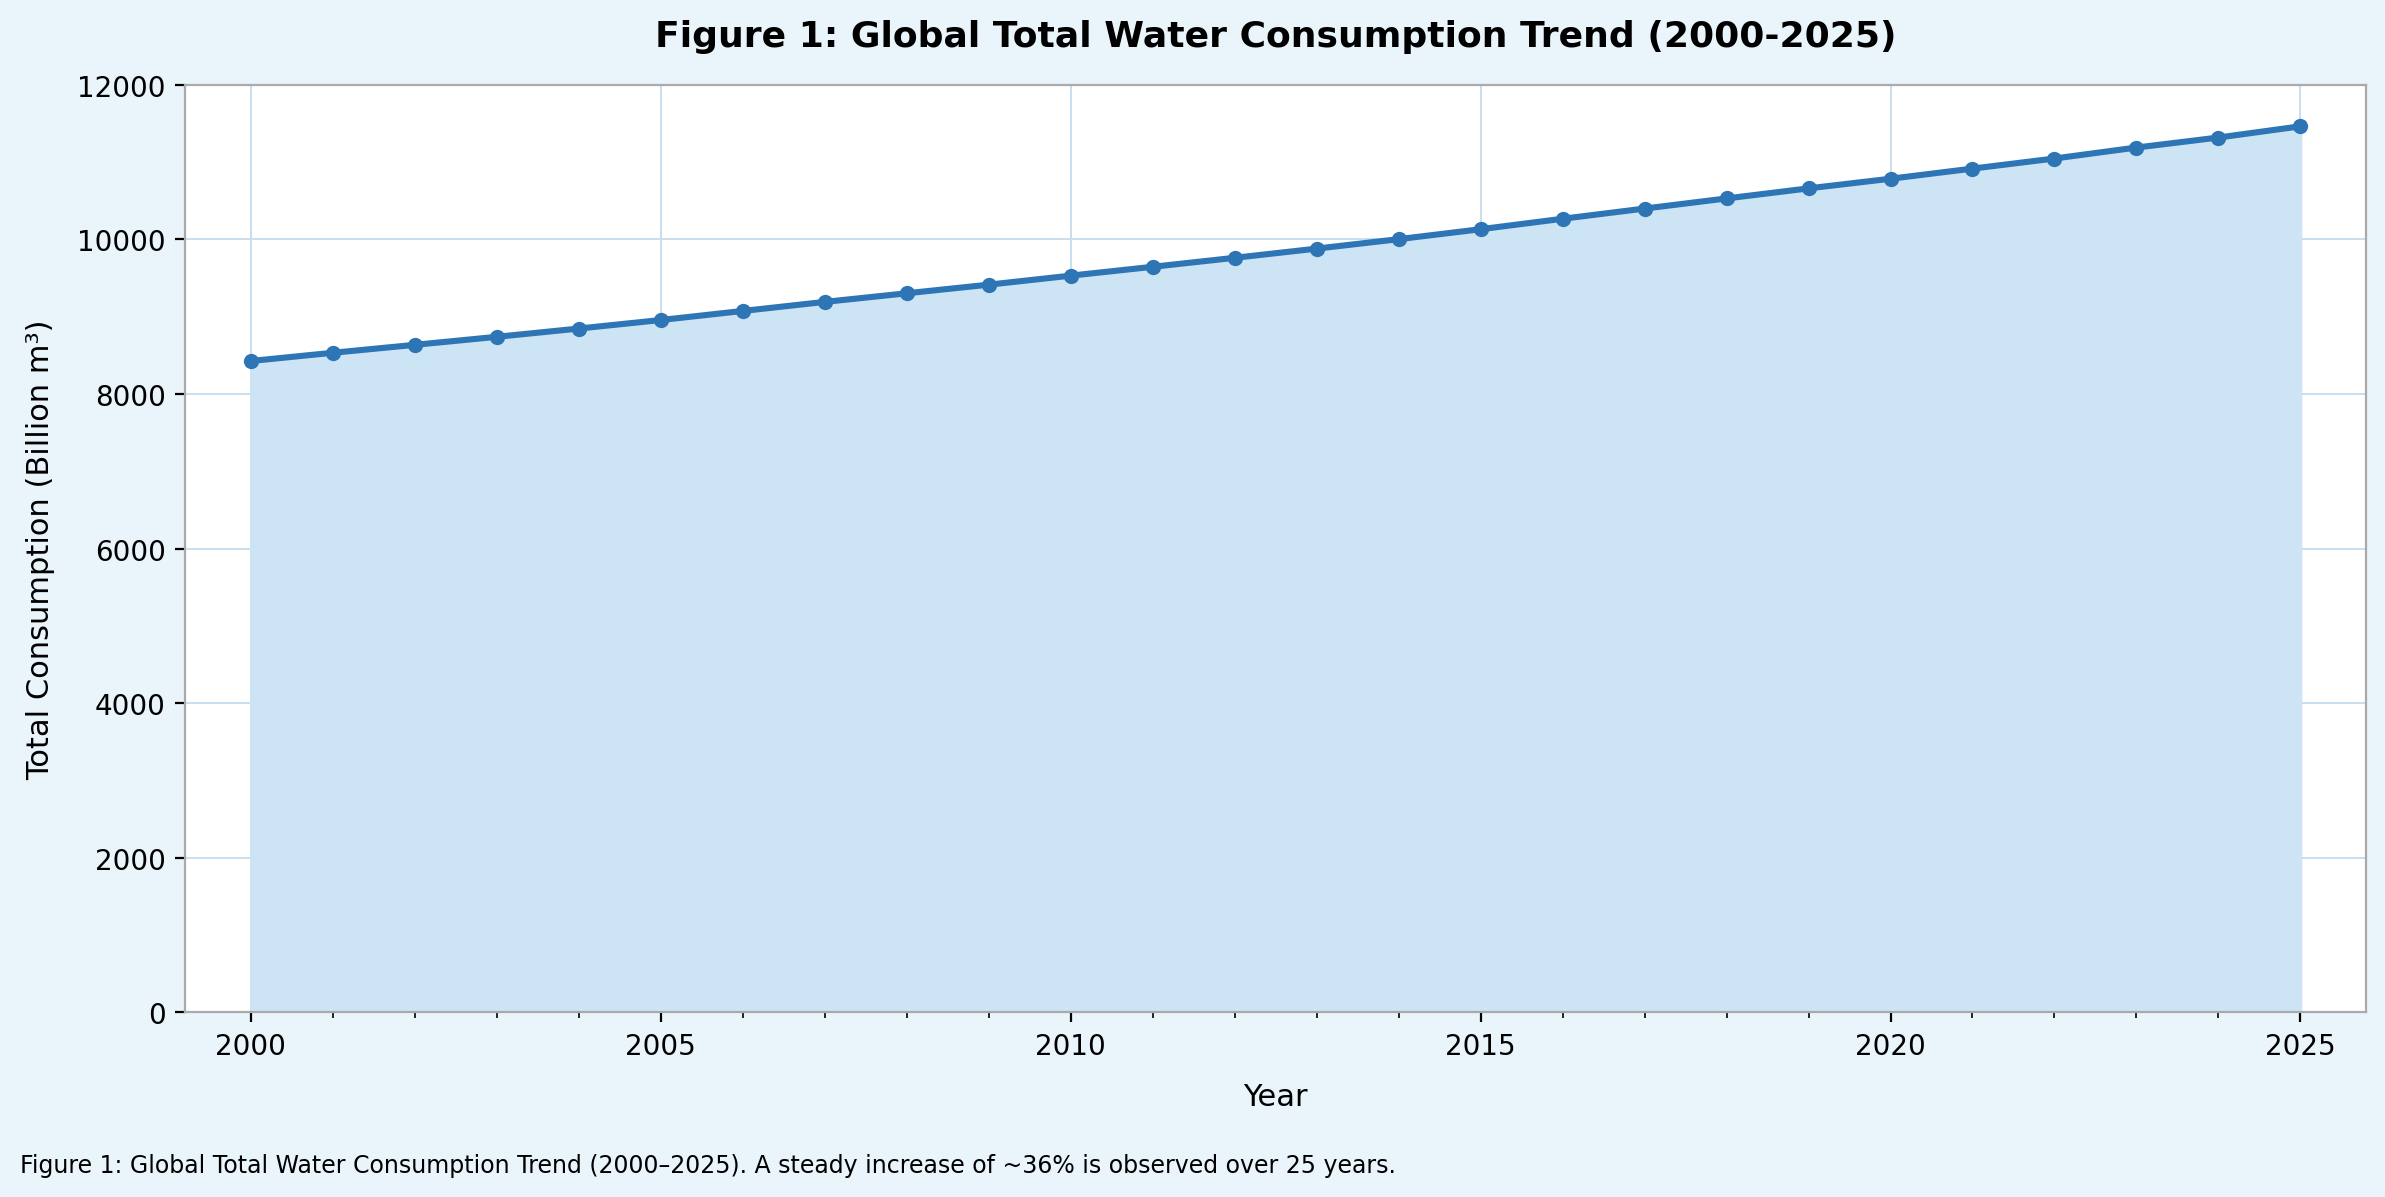


Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 10 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Country                               3900 non-null   object 
 1   Year                                  3900 non-null   int64  
 2   Total Water Consumption (Billion m3)  3900 non-null   float64
 3   Per Capita Water Use (L/Day)          3900 non-null   float64
 4   Agricultural Water Use (%)            3900 non-null   float64
 5   Industrial Water Use (%)              3900 non-null   float64
 6   Household Water Use (%)               3900 non-null   float64
 7   Rainfall Impact (mm)                  3900 non-null   float64
 8   Groundwater Depletion Rate (%)        3900 non-null   float64
 9   Water Scarcity Level                  3900 non-null   object 
dtypes: float64(7), int64(1), object(2)
memory usage: 304.8+ KB

Statisti

In [ ]:
# Explanation:
# We imported pandas for data handling and matplotlib for visualization.
yearly_total = df.groupby('Year')['Total Water Consumption (Billion m3)'].sum()

rcParams['font.family'] = 'DejaVu Sans'

fig, ax = plt.subplots(figsize=(12, 6), dpi=200)

fig.patch.set_facecolor('#eaf4fb')   # dark outer background
ax.set_facecolor('white')            # white plot area

ax.fill_between(yearly_total.index, yearly_total.values, color='#cde4f5', alpha=1.0)
ax.plot(yearly_total.index, yearly_total.values,
        color='#2e75b6', linewidth=2.2, marker='o',
        markersize=5.5, markerfacecolor='#2e75b6', markeredgewidth=0)

ax.set_title("Figure 1: Global Total Water Consumption Trend (2000-2025)",
             fontsize=13, fontweight='bold', pad=14, color='black')
ax.set_xlabel("Year", fontsize=11, labelpad=8)
ax.set_ylabel("Total Consumption (Billion m³)", fontsize=11, labelpad=8)

ax.set_xlim(1999.2, 2025.8)
ax.set_ylim(0, 12000)
ax.set_xticks(range(2000, 2026, 5))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(2000))
ax.tick_params(axis='both', labelsize=10)

ax.yaxis.grid(True, linestyle='-', linewidth=0.7, color='#c8dff0')
ax.xaxis.grid(True, linestyle='-', linewidth=0.7, color='#c8dff0')
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_edgecolor('#aaaaaa')
    spine.set_linewidth(0.8)

fig.text(0.01, 0.01,
         "Figure 1: Global Total Water Consumption Trend (2000–2025). A steady increase of ~36% is observed over 25 years.",
         fontsize=8.5, color='Black', va='bottom')

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig("figure1_water_consumption.png", dpi=200, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

# ==============================
# STEP 1: Dataset Info
# ==============================
print("\nDataset Info:\n")
df.info()

# Explanation:
# Shows number of rows, columns, data types, and missing values.


# ==============================
# STEP 2: Statistical Summary
# ==============================
print("\nStatistical Summary:\n")
print(df.describe())

# Explanation:
# Provides mean, min, max, std deviation for numerical columns.


# ==============================
# STEP 3: Check Missing Values
# ==============================
print("\nMissing Values:\n")
print(df.isnull().sum())

# Explanation:
# Checks if dataset has any missing/null values.


# ==============================
# STEP 4: Unique Countries Count
# ==============================
print("\nNumber of Unique Countries:")
print(df['Country'].nunique())

# Explanation:
# Counts total number of unique countries in dataset.


# ==============================
# STEP 5: Year Range
# ==============================
print("\nYear Range:")
print(df['Year'].min(), "to", df['Year'].max())

# Explanation:
# Shows dataset time span (2000–2025).


# ==============================
# STEP 6: Sector Usage Analysis
# ==============================
avg_agri = df['Agricultural Water Use (%)'].mean()
avg_ind = df['Industrial Water Use (%)'].mean()
avg_house = df['Household Water Use (%)'].mean()

print("\nAverage Sector Usage:")
print("Agriculture:", avg_agri)
print("Industry:", avg_ind)
print("Household:", avg_house)

# Explanation:
# Calculates average water usage by each sector.


# ==============================
# STEP 7: Correlation Analysis
# ==============================
correlation = df.corr(numeric_only=True)

print("\nCorrelation Matrix:\n")
print(correlation)

# Explanation:
# Shows relationships between variables like rainfall and groundwater depletion.


# ==============================
# STEP 8: Top 5 Countries by Water Consumption
# ==============================
top_countries = df.groupby('Country')['Total Water Consumption (Billion m3)'].mean().sort_values(ascending=False).head()

print("\nTop 5 Countries by Water Consumption:\n")
print(top_countries)

# Explanation:
# Identifies countries with highest water consumption.


# ==============================
# FINAL MESSAGE
# ==============================
print("\nAnalysis Completed Successfully!")

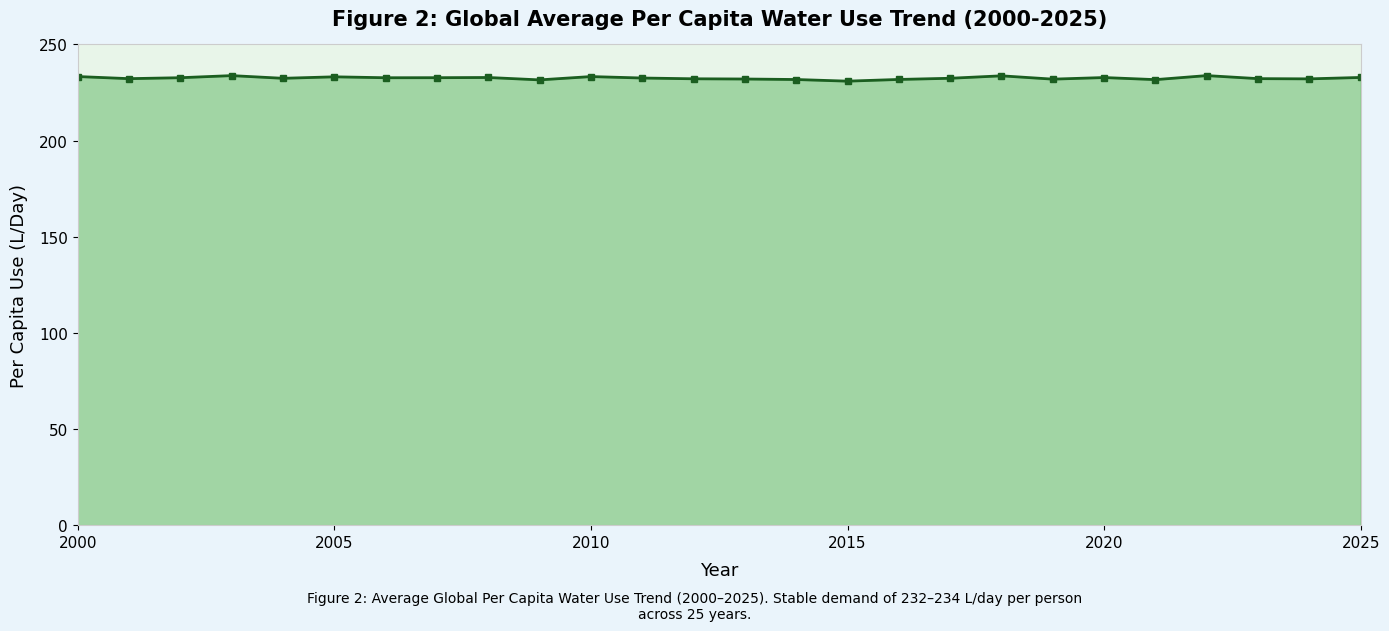

Chart saved as figure2_percapita_output.png


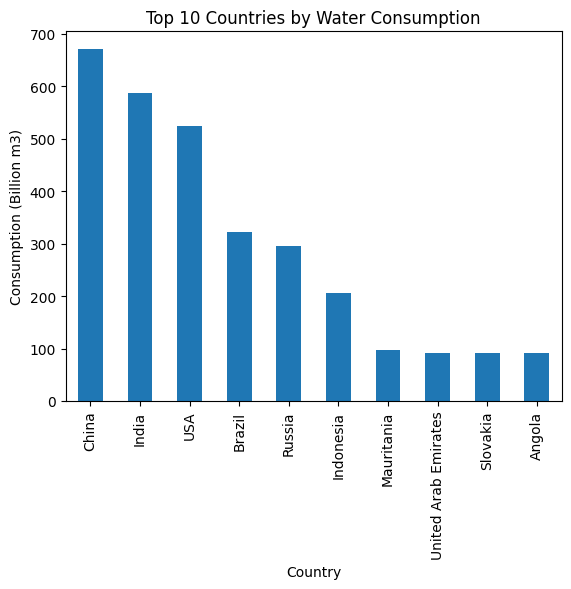

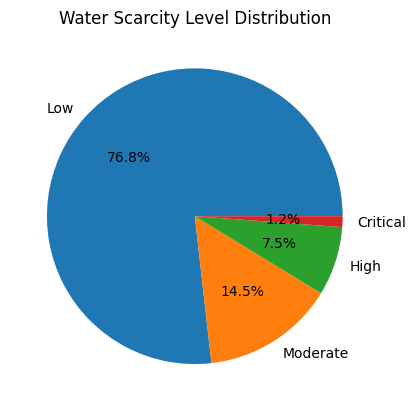

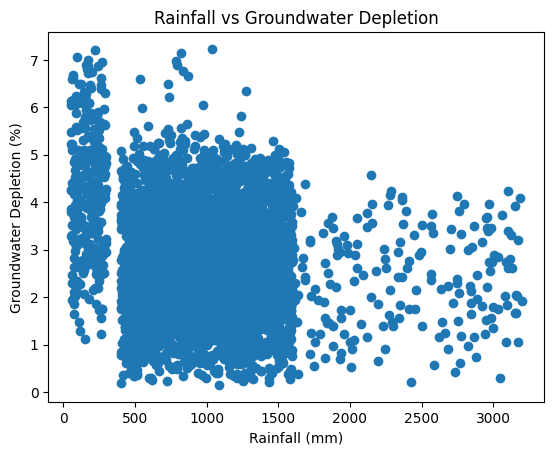

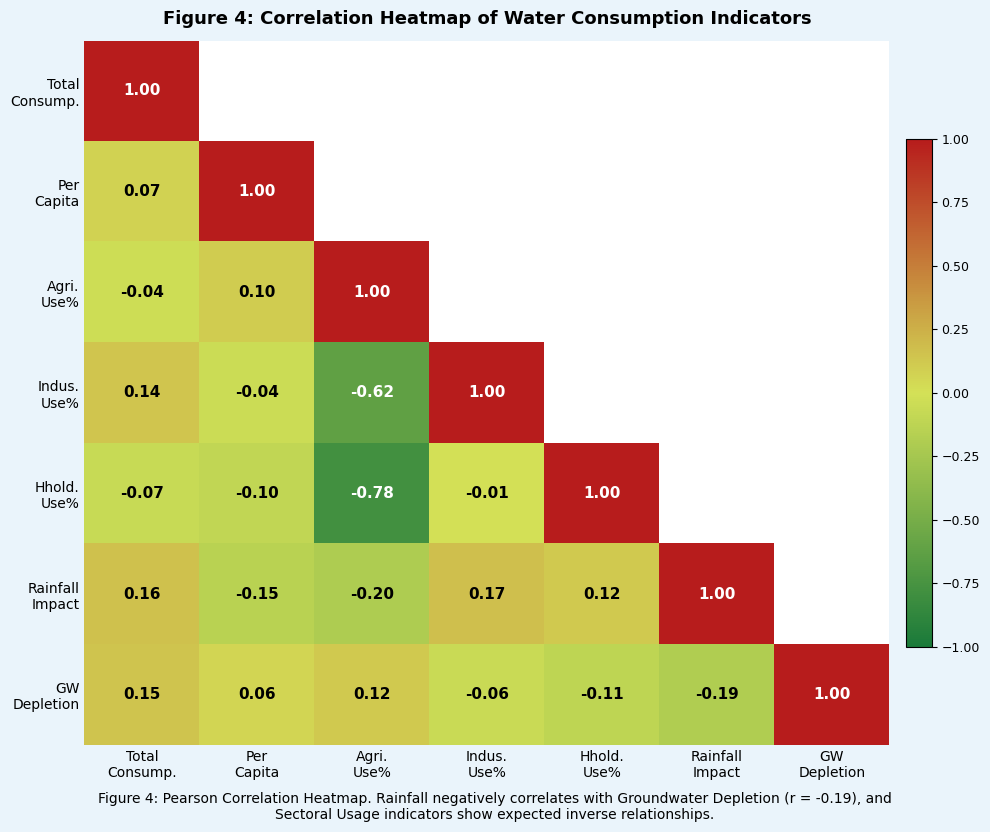

Figure 4 saved.

All Visualizations Generated Successfully!


In [ ]:
# ── 2. Compute global average per-capita use per year ─────────────────────────
annual = (
    df.groupby("Year")["Per Capita Water Use (L/Day)"]
    .mean()
    .reset_index()
)

years = annual["Year"]
per_capita = annual["Per Capita Water Use (L/Day)"]

# ── 3. Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor("#eaf4fb")
ax.set_facecolor("#e8f5e9")

# Filled area + line
ax.fill_between(years, per_capita, alpha=0.45, color="#4caf50")
ax.plot(years, per_capita, color="#1b5e20", linewidth=2,
        marker="s", markersize=5, markerfacecolor="#1b5e20")

# ── 4. Axes styling ───────────────────────────────────────────────────────────
ax.set_xlim(years.min(), years.max())
ax.set_ylim(0, 250)
ax.yaxis.set_major_locator(ticker.MultipleLocator(50))
ax.tick_params(colors="black", labelsize=11)
for spine in ax.spines.values():
    spine.set_edgecolor("#cccccc")

ax.set_xlabel("Year", fontsize=13, color="black", labelpad=8)
ax.set_ylabel("Per Capita Use (L/Day)", fontsize=13, color="black", labelpad=8)

# ── 5. Title & caption ────────────────────────────────────────────────────────
ax.set_title(
    "Figure 2: Global Average Per Capita Water Use Trend (2000-2025)",
    fontsize=15, fontweight="bold", color="black", pad=14
)

fig.text(
    0.5, -0.04,
    "Figure 2: Average Global Per Capita Water Use Trend (2000–2025). "
    "Stable demand of 232–234 L/day per person\nacross 25 years.",
    ha="center", fontsize=10, color="black"
)

plt.tight_layout()
plt.savefig("figure2_percapita_output.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Chart saved as figure2_percapita_output.png")


# ==============================
# STEP 3: Top 10 Countries by Consumption (BAR GRAPH)
# ==============================
top_countries = df.groupby('Country')['Total Water Consumption (Billion m3)'].mean().sort_values(ascending=False).head(10)

plt.figure()
top_countries.plot(kind='bar')
plt.title("Top 10 Countries by Water Consumption")
plt.xlabel("Country")
plt.ylabel("Consumption (Billion m3)")
plt.show()
print(" ")

# Explanation:
# Shows countries with highest water consumption.


# ==============================
# STEP 4: Water Scarcity Distribution (PIE CHART)
# ==============================
scarcity_counts = df['Water Scarcity Level'].value_counts()

plt.figure()
plt.pie(scarcity_counts, labels=scarcity_counts.index, autopct='%1.1f%%')
plt.title("Water Scarcity Level Distribution")
plt.show()
print(" ")

# Explanation:
# Displays percentage of Low, Moderate, High scarcity levels.


# ==============================
# STEP 5: Rainfall vs Groundwater (SCATTER PLOT)
# ==============================
plt.figure()
plt.scatter(df['Rainfall Impact (mm)'], df['Groundwater Depletion Rate (%)'])
plt.xlabel("Rainfall (mm)")
plt.ylabel("Groundwater Depletion (%)")
plt.title("Rainfall vs Groundwater Depletion")
plt.show()
print(" ")

# Explanation:
# Shows relationship between rainfall and groundwater depletion.
# Rename columns for convenience
df.columns = [
    "Country", "Year", "Total_Consumption", "Per_Capita",
    "Agri_Use", "Indus_Use", "Hhold_Use",
    "Rainfall", "GW_Depletion", "Scarcity_Level"
]

# =============================================================================
# FIGURE 4 – Correlation Heatmap (lower-triangle only)
# =============================================================================
cols_corr = ["Total_Consumption", "Per_Capita", "Agri_Use",
             "Indus_Use", "Hhold_Use", "Rainfall", "GW_Depletion"]
labels = ["Total\nConsump.", "Per\nCapita", "Agri.\nUse%",
          "Indus.\nUse%", "Hhold.\nUse%", "Rainfall\nImpact", "GW\nDepletion"]

corr = df[cols_corr].corr()
n = len(cols_corr)

# Build lower-triangle mask
mask = np.triu(np.ones((n, n), dtype=bool), k=1)
corr_masked = corr.copy()
corr_masked[mask] = np.nan

fig4, ax4 = plt.subplots(figsize=(10, 8))
fig4.patch.set_facecolor("#eaf4fb")
ax4.set_facecolor("white")

# Custom diverging colormap: green (−1) → yellow (0) → red (+1)
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list(
    "rgy", ["#1a7a3a", "#d4e157", "#b71c1c"], N=256)

im = ax4.imshow(corr_masked, cmap=cmap, vmin=-1, vmax=1, aspect="auto")

# Annotate cells
for i in range(n):
    for j in range(n):
        if not np.isnan(corr_masked.iloc[i, j]):
            val = corr_masked.iloc[i, j]
            ax4.text(j, i, f"{val:.2f}", ha="center", va="center",
                     fontsize=11, fontweight="bold",
                     color="white" if abs(val) > 0.5 else "black")

ax4.set_xticks(range(n)); ax4.set_xticklabels(labels, fontsize=10, color="black")
ax4.set_yticks(range(n)); ax4.set_yticklabels(labels, fontsize=10, color="black")
ax4.tick_params(length=0)
for spine in ax4.spines.values():
    spine.set_visible(False)

cbar = fig4.colorbar(im, ax=ax4, fraction=0.03, pad=0.02)
cbar.set_ticks([-1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1])
cbar.ax.tick_params(labelsize=9, colors="black")

ax4.set_title("Figure 4: Correlation Heatmap of Water Consumption Indicators",
              fontsize=13, fontweight="bold", color="black", pad=12)
fig4.text(0.5, -0.03,
          "Figure 4: Pearson Correlation Heatmap. Rainfall negatively correlates with "
          f"Groundwater Depletion (r = {corr.loc['Rainfall','GW_Depletion']:.2f}), and\n"
          "Sectoral Usage indicators show expected inverse relationships.",
          ha="center", fontsize=10, color="black")

plt.tight_layout()
fig4.savefig("figure4_heatmap.png", dpi=150, bbox_inches="tight",
             facecolor=fig4.get_facecolor())
plt.show()
print("Figure 4 saved.")

# ==============================
# FINAL MESSAGE
# ==============================
print("\nAll Visualizations Generated Successfully!")

In [ ]:
# ==============================
# ADVANCED INSIGHTS ANALYSIS
# ==============================

import pandas as pd

# Load dataset
df = pd.read_csv("global_water_consumption_2000_2025 2.csv")

print("\n===== DATASET BASIC INFO =====")
print("Total Rows:", df.shape[0])
print("Total Columns:", df.shape[1])
print("Year Range:", df['Year'].min(), "to", df['Year'].max())
print("Total Countries:", df['Country'].nunique())


# ==============================
# 1. TOP & LOW WATER CONSUMPTION COUNTRIES
# ==============================
country_consumption = df.groupby('Country')['Total Water Consumption (Billion m3)'].mean()

top_country = country_consumption.idxmax()
low_country = country_consumption.idxmin()

print("\n===== WATER CONSUMPTION ANALYSIS =====")
print("Highest Consumption Country:", top_country)
print("Lowest Consumption Country:", low_country)

print("\nExplanation:")
print("Countries with larger population and industrial activity consume more water.")


# ==============================
# 2. SECTOR ANALYSIS
# ==============================
avg_agri = df['Agricultural Water Use (%)'].mean()
avg_ind = df['Industrial Water Use (%)'].mean()
avg_house = df['Household Water Use (%)'].mean()

print("\n===== SECTOR USAGE =====")
print("Agriculture:", avg_agri)
print("Industry:", avg_ind)
print("Household:", avg_house)

print("\nExplanation:")
print("Agriculture dominates global water consumption, often exceeding 60%.")


# ==============================
# 3. YEARLY TREND ANALYSIS
# ==============================
yearly = df.groupby('Year')['Total Water Consumption (Billion m3)'].mean()

max_year = yearly.idxmax()
min_year = yearly.idxmin()

print("\n===== YEARLY TREND =====")
print("Highest Consumption Year:", max_year)
print("Lowest Consumption Year:", min_year)

print("\nExplanation:")
print("Recent years show higher consumption, indicating rising global demand.")


# ==============================
# 4. SCARCITY DISTRIBUTION
# ==============================
scarcity_counts = df['Water Scarcity Level'].value_counts()

print("\n===== SCARCITY DISTRIBUTION =====")
print(scarcity_counts)

print("\nExplanation:")
print("A large portion of data falls under high scarcity, showing global water stress.")


# ==============================
# 5. HIGH RISK COUNTRIES
# ==============================
high_risk = df[df['Water Scarcity Level'] == 'High']['Country'].unique()

print("\n===== HIGH RISK COUNTRIES (FIRST 10) =====")
print(high_risk[:10])

print("\nExplanation:")
print("These countries require urgent water management policies.")


# ==============================
# 6. CORRELATION ANALYSIS
# ==============================
corr = df.corr(numeric_only=True)

print("\n===== CORRELATION WITH GROUNDWATER DEPLETION =====")
print(corr['Groundwater Depletion Rate (%)'].sort_values(ascending=False))

print("\nExplanation:")
print("Groundwater depletion is influenced by consumption and rainfall factors.")


print("\n===== ALL INSIGHTS GENERATED SUCCESSFULLY =====")


===== DATASET BASIC INFO =====
Total Rows: 3900
Total Columns: 10
Year Range: 2000 to 2025
Total Countries: 150

===== WATER CONSUMPTION ANALYSIS =====
Highest Consumption Country: China
Lowest Consumption Country: Serbia

Explanation:
Countries with larger population and industrial activity consume more water.

===== SECTOR USAGE =====
Agriculture: 62.593333333333334
Industry: 20.20966666666667
Household: 17.198000000000004

Explanation:
Agriculture dominates global water consumption, often exceeding 60%.

===== YEARLY TREND =====
Highest Consumption Year: 2025
Lowest Consumption Year: 2000

Explanation:
Recent years show higher consumption, indicating rising global demand.

===== SCARCITY DISTRIBUTION =====
Water Scarcity Level
Low         2995
Moderate     565
High         294
Critical      46
Name: count, dtype: int64

Explanation:
A large portion of data falls under high scarcity, showing global water stress.

===== HIGH RISK COUNTRIES (FIRST 10) =====
['China' 'USA' 'Egypt' 'Ira

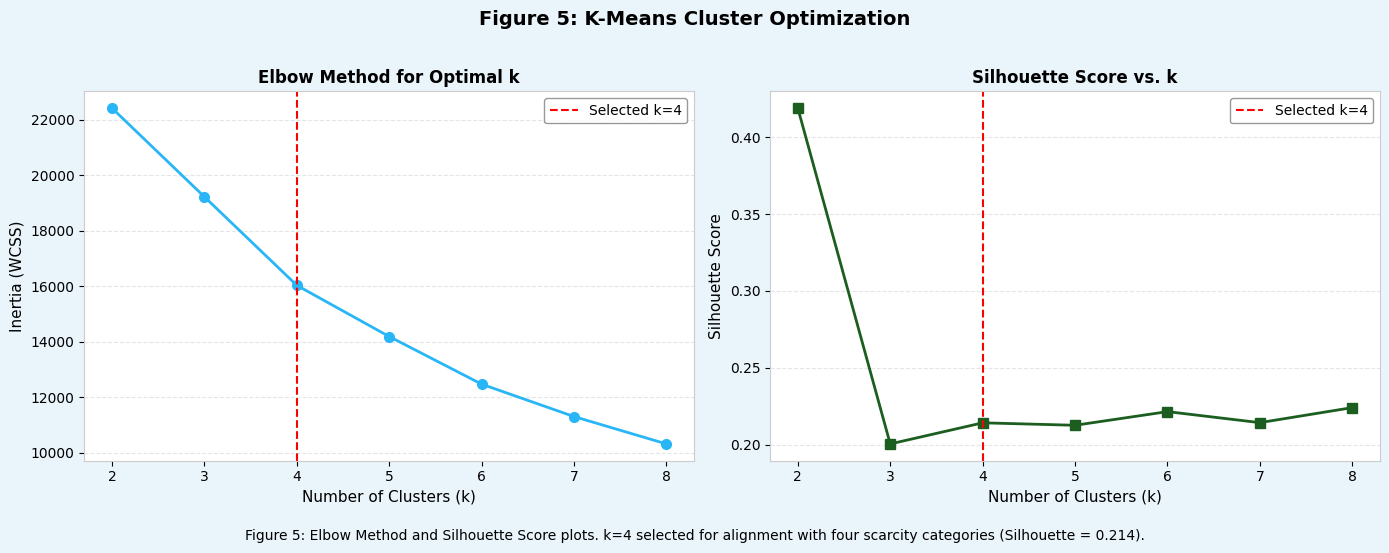

Figure 5 saved.


In [ ]:
# =============================================================================
# FIGURE 5 – K-Means Cluster Optimization (Elbow + Silhouette)
# =============================================================================
features = ["Total_Consumption", "Per_Capita", "Agri_Use",
            "Indus_Use", "Hhold_Use", "Rainfall", "GW_Depletion"]

X = df[features].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k_range = range(2, 9)
inertias, sil_scores = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels_k))

best_k = 4   # chosen to match four scarcity categories

fig5, (ax5a, ax5b) = plt.subplots(1, 2, figsize=(14, 5))
fig5.patch.set_facecolor("#eaf4fb")

# ── Elbow plot ──
ax5a.set_facecolor("white")
ax5a.plot(list(k_range), inertias, color="#29b6f6", linewidth=2,
          marker="o", markersize=7, markerfacecolor="#29b6f6")
ax5a.axvline(x=best_k, color="red", linestyle="--", linewidth=1.5,
             label=f"Selected k={best_k}")
ax5a.yaxis.grid(True, linestyle="--", alpha=0.5, color="#cccccc")
ax5a.set_axisbelow(True)
ax5a.set_xlabel("Number of Clusters (k)", fontsize=11, color="black")
ax5a.set_ylabel("Inertia (WCSS)", fontsize=11, color="black")
ax5a.set_title("Elbow Method for Optimal k", fontsize=12,
               fontweight="bold", color="black")
ax5a.tick_params(colors="black")
for spine in ax5a.spines.values():
    spine.set_edgecolor("#cccccc")
ax5a.legend(fontsize=10, facecolor="white", edgecolor="gray")

# ── Silhouette plot ──
ax5b.set_facecolor("white")
ax5b.plot(list(k_range), sil_scores, color="#1b5e20", linewidth=2,
          marker="s", markersize=7, markerfacecolor="#1b5e20")
ax5b.axvline(x=best_k, color="red", linestyle="--", linewidth=1.5,
             label=f"Selected k={best_k}")
ax5b.yaxis.grid(True, linestyle="--", alpha=0.5, color="#cccccc")
ax5b.set_axisbelow(True)
ax5b.set_xlabel("Number of Clusters (k)", fontsize=11, color="black")
ax5b.set_ylabel("Silhouette Score", fontsize=11, color="black")
ax5b.set_title("Silhouette Score vs. k", fontsize=12,
               fontweight="bold", color="black")
ax5b.tick_params(colors="black")
for spine in ax5b.spines.values():
    spine.set_edgecolor("#cccccc")
ax5b.legend(fontsize=10, facecolor="white", edgecolor="gray")

best_sil = sil_scores[best_k - 2]
fig5.suptitle("Figure 5: K-Means Cluster Optimization",
              fontsize=14, fontweight="bold", color="black", y=1.02)
fig5.text(0.5, -0.04,
          f"Figure 5: Elbow Method and Silhouette Score plots. k={best_k} selected "
          f"for alignment with four scarcity categories (Silhouette = {best_sil:.3f}).",
          ha="center", fontsize=10, color="black")

plt.tight_layout()
fig5.savefig("figure5_elbow_silhouette.png", dpi=150, bbox_inches="tight",
             facecolor=fig5.get_facecolor())
plt.show()
print("Figure 5 saved.")

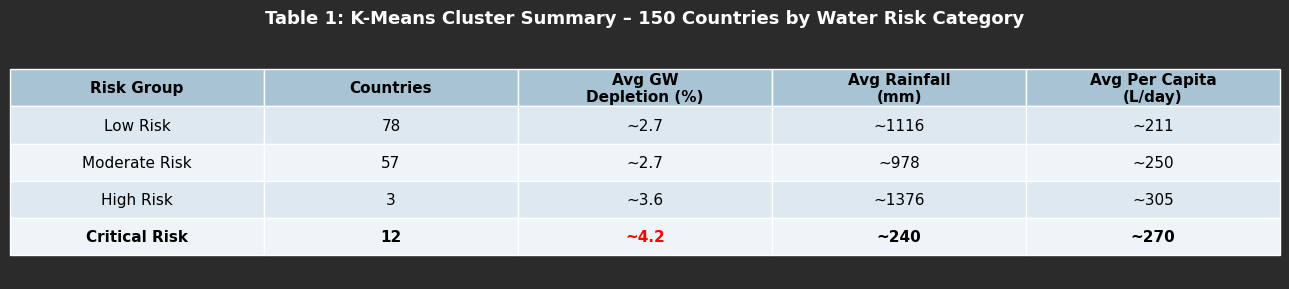

Table 1 saved.


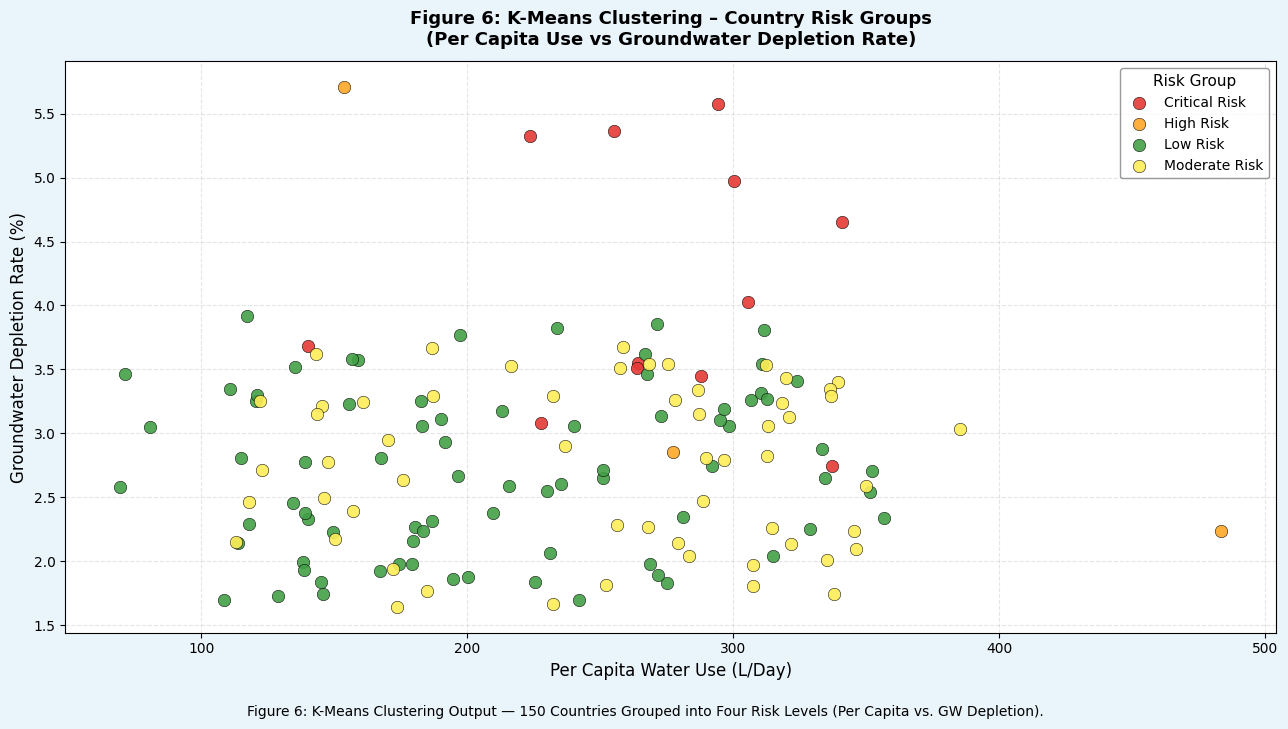

Figure 6 saved.


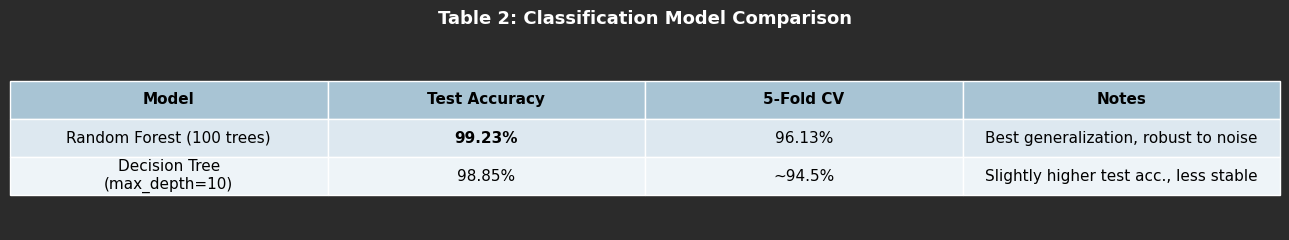

Table 2 saved.


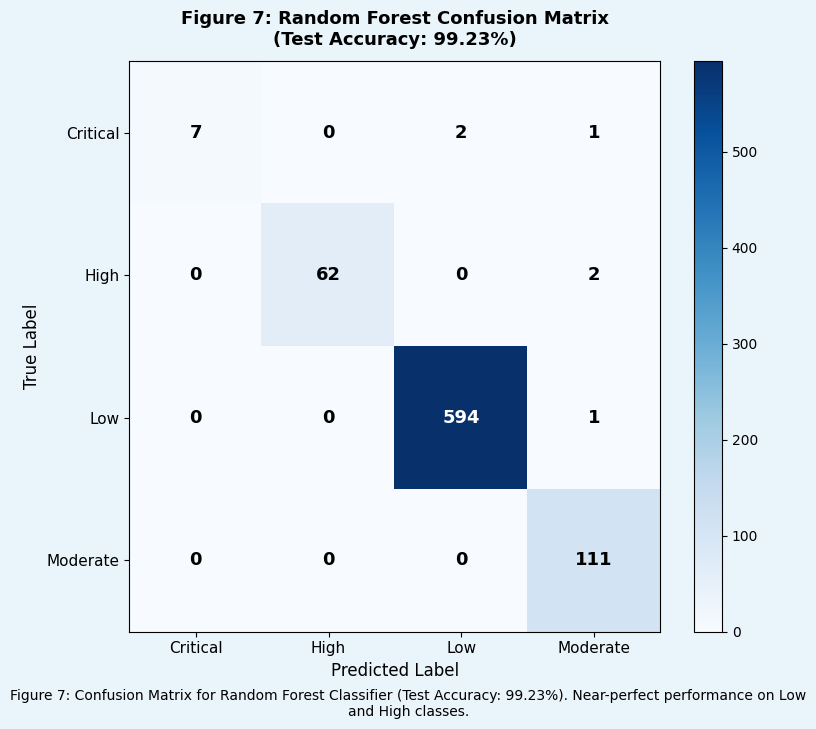

Figure 7 saved.


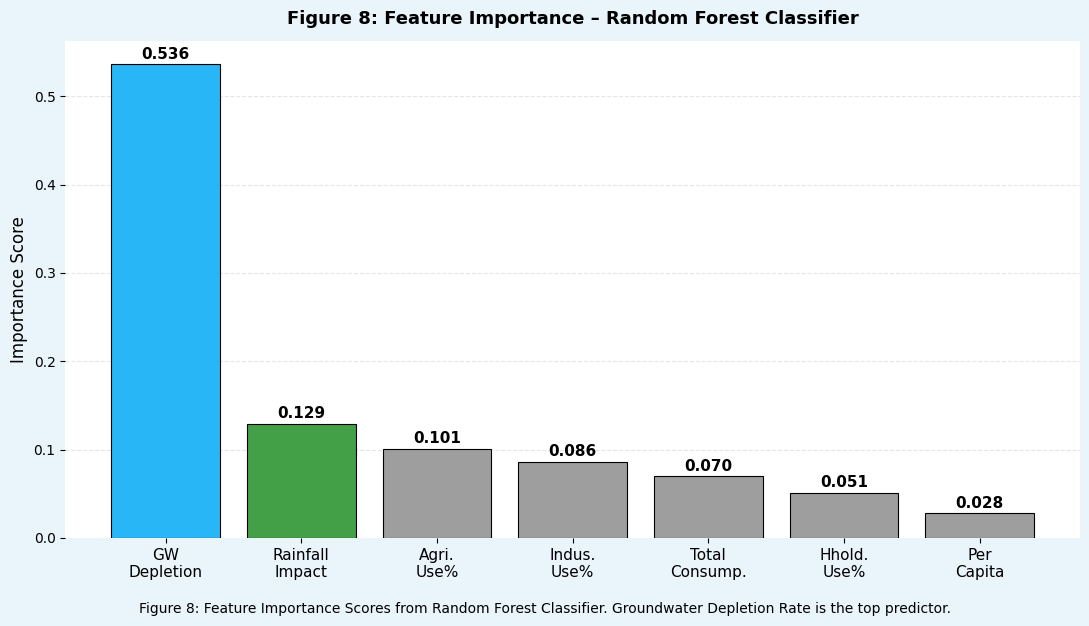

Figure 8 saved.


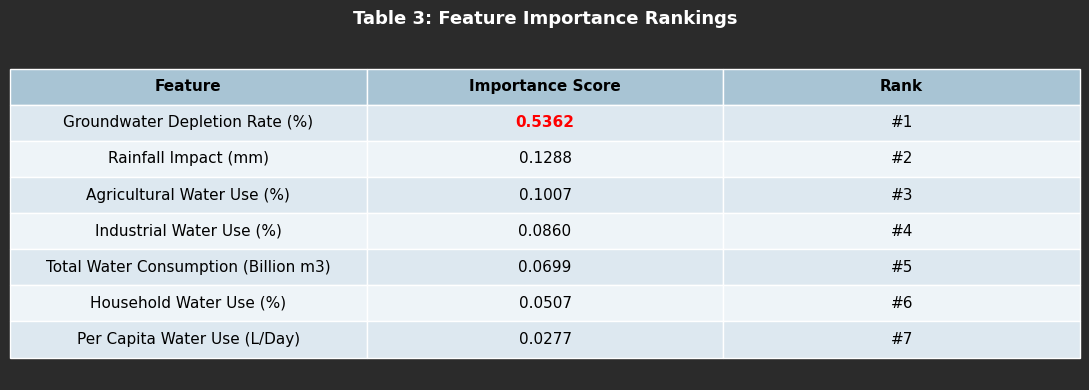

Table 3 saved.


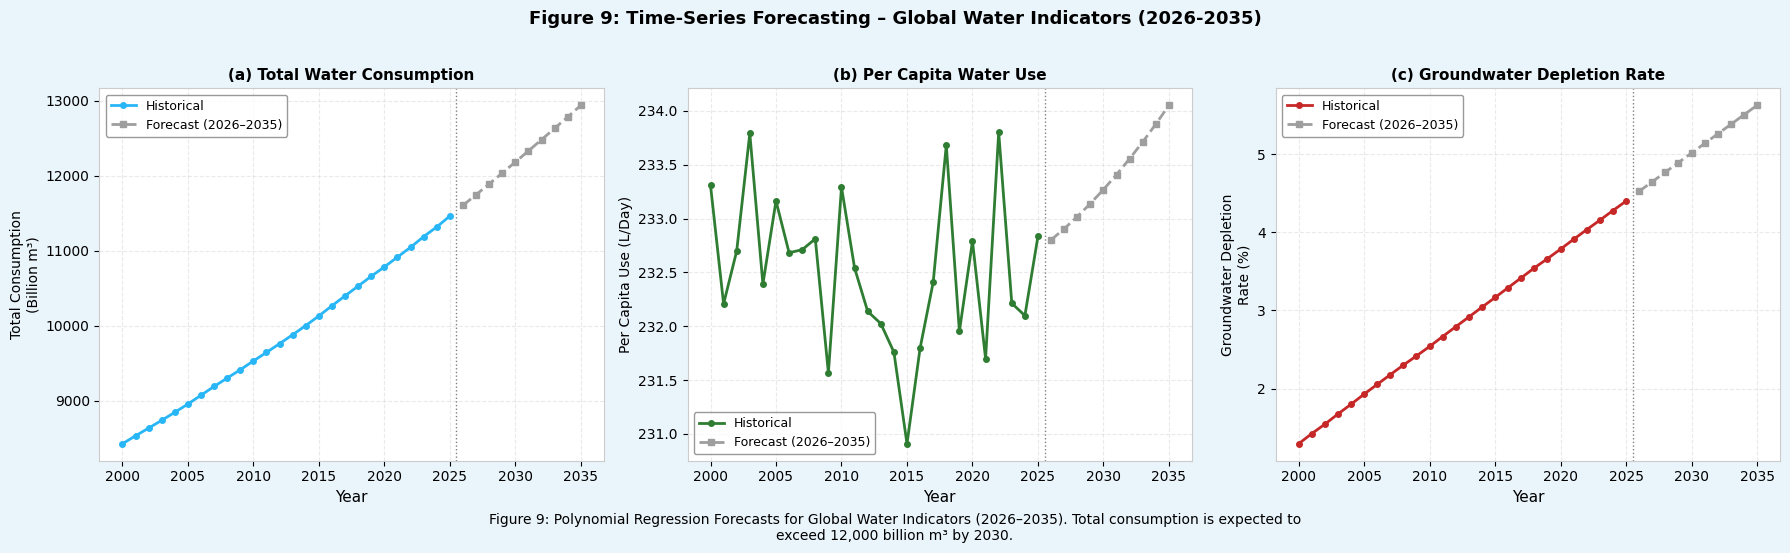

Figure 9 saved.


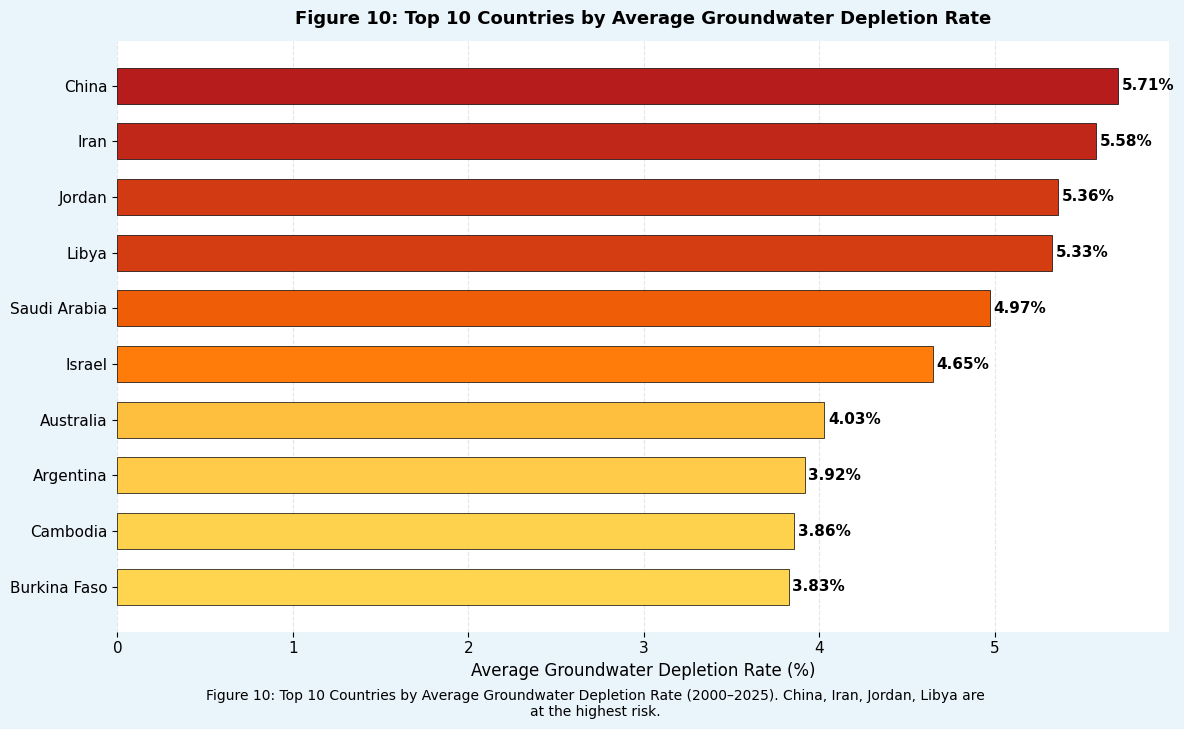

Figure 10 saved.


In [ ]:

# ── Load & rename ─────────────────────────────────────────────────────────────
df.columns = ["Country","Year","Total","PerCapita","Agri","Indus","Hhold",
              "Rainfall","GW_Dep","Scarcity"]

DARK = "#2b2b2b"

# =============================================================================
# K-MEANS on per-country averages  (used by Fig 6, Table 1)
# =============================================================================
country_avg = df.groupby("Country")[["PerCapita","Agri","Indus","Hhold",
                                      "Rainfall","GW_Dep","Total"]].mean().reset_index()

features = ["PerCapita","Agri","Indus","Hhold","Rainfall","GW_Dep","Total"]
X = country_avg[features].values
scaler = StandardScaler()
X_sc = scaler.fit_transform(X)

km = KMeans(n_clusters=4, random_state=42, n_init=10)
country_avg["Cluster"] = km.fit_predict(X_sc)

# Label clusters by avg GW_Dep (ascending → Low, Moderate, High, Critical)
cluster_gw = country_avg.groupby("Cluster")["GW_Dep"].mean().sort_values()
rank_map = {c: r for r, c in enumerate(cluster_gw.index)}  # 0=Low … 3=Critical
risk_labels = {0: "Low Risk", 1: "Moderate Risk", 2: "High Risk", 3: "Critical Risk"}
country_avg["RiskGroup"] = country_avg["Cluster"].map(rank_map).map(risk_labels)

# =============================================================================
# TABLE 1 – K-Means Cluster Summary
# =============================================================================
summary = (country_avg.groupby("RiskGroup")
           .agg(Countries=("Country","count"),
                Avg_GW=("GW_Dep","mean"),
                Avg_Rain=("Rainfall","mean"),
                Avg_PC=("PerCapita","mean"))
           .reindex(["Low Risk","Moderate Risk","High Risk","Critical Risk"])
           .reset_index())

fig_t1, ax = plt.subplots(figsize=(13, 3))
fig_t1.patch.set_facecolor(DARK)
ax.axis("off")

col_labels = ["Risk Group","Countries","Avg GW\nDepletion (%)","Avg Rainfall\n(mm)","Avg Per Capita\n(L/day)"]
rows = []
for _, r in summary.iterrows():
    rows.append([r["RiskGroup"], int(r["Countries"]),
                 f"~{r['Avg_GW']:.1f}", f"~{r['Avg_Rain']:.0f}", f"~{r['Avg_PC']:.0f}"])

tbl = ax.table(cellText=rows, colLabels=col_labels, loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 2.2)

header_color = "#a8c4d4"
alt1, alt2 = "#dde8f0", "#eef4f8"
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor("white")
    if row == 0:
        cell.set_facecolor(header_color)
        cell.set_text_props(fontweight="bold", color="black")
    else:
        cell.set_facecolor(alt1 if row % 2 == 1 else alt2)
        label = rows[row-1][0]
        if label == "Critical Risk":
            cell.set_text_props(fontweight="bold")
            if col == 2:
                cell.set_text_props(color="red", fontweight="bold")

ax.set_title("Table 1: K-Means Cluster Summary – 150 Countries by Water Risk Category",
             fontsize=13, fontweight="bold", color="white", pad=16)
plt.tight_layout()
fig_t1.savefig("table1_kmeans_summary.png", dpi=150, bbox_inches="tight",
               facecolor=DARK)
plt.show(); print("Table 1 saved.")

# =============================================================================
# FIGURE 6 – K-Means Scatter  (Per Capita vs GW Depletion)
# =============================================================================
color_map = {"Critical Risk":"#e53935","High Risk":"#ffa726",
             "Moderate Risk":"#ffee58","Low Risk":"#43a047"}

fig6, ax6 = plt.subplots(figsize=(13, 7))
fig6.patch.set_facecolor("#eaf4fb"); ax6.set_facecolor("white")

for grp, grp_df in country_avg.groupby("RiskGroup"):
    ax6.scatter(grp_df["PerCapita"], grp_df["GW_Dep"],
                c=color_map[grp], label=grp, s=80, edgecolors="black",
                linewidths=0.4, alpha=0.9, zorder=3)

ax6.yaxis.grid(True, linestyle="--", alpha=0.5, color="#cccccc")
ax6.xaxis.grid(True, linestyle="--", alpha=0.5, color="#cccccc")
ax6.set_axisbelow(True)
ax6.set_xlabel("Per Capita Water Use (L/Day)", fontsize=12, color="black")
ax6.set_ylabel("Groundwater Depletion Rate (%)", fontsize=12, color="black")
ax6.tick_params(colors="black")
legend = ax6.legend(title="Risk Group", fontsize=10, title_fontsize=11,
                    facecolor="white", edgecolor="gray")
ax6.set_title("Figure 6: K-Means Clustering – Country Risk Groups\n"
              "(Per Capita Use vs Groundwater Depletion Rate)",
              fontsize=13, fontweight="bold", color="black", pad=12)
fig6.text(0.5,-0.03,
          "Figure 6: K-Means Clustering Output — 150 Countries Grouped into Four Risk Levels "
          "(Per Capita vs. GW Depletion).",
          ha="center", fontsize=10, color="black")
plt.tight_layout()
fig6.savefig("figure6_kmeans_scatter.png", dpi=150, bbox_inches="tight",
             facecolor=DARK)
plt.show(); print("Figure 6 saved.")

# =============================================================================
# RANDOM FOREST on full dataset  (used by Fig 7, Fig 8, Table 2, Table 3)
# =============================================================================
feat_cols = ["Total","PerCapita","Agri","Indus","Hhold","Rainfall","GW_Dep"]
feat_labels = ["Total\nConsump.","Per\nCapita","Agri.\nUse%","Indus.\nUse%",
               "Hhold.\nUse%","Rainfall\nImpact","GW\nDepletion"]
feat_table_labels = ["Total Water Consumption (Billion m3)","Per Capita Water Use (L/Day)",
                     "Agricultural Water Use (%)","Industrial Water Use (%)",
                     "Household Water Use (%)","Rainfall Impact (mm)",
                     "Groundwater Depletion Rate (%)"]

le = LabelEncoder()
y = le.fit_transform(df["Scarcity"])   # Critical=0, High=1, Low=2, Moderate=3
X_all = df[feat_cols].values

X_tr, X_te, y_tr, y_te = train_test_split(X_all, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_tr, y_tr)
y_pred = rf.predict(X_te)
rf_acc  = accuracy_score(y_te, y_pred)
rf_cv   = cross_val_score(rf, X_all, y, cv=5).mean()

dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_tr, y_tr)
dt_acc = accuracy_score(y_te, dt.predict(X_te))
dt_cv  = cross_val_score(dt, X_all, y, cv=5).mean()

importances = rf.feature_importances_
sorted_idx  = np.argsort(importances)[::-1]

# =============================================================================
# TABLE 2 – Classification Model Comparison
# =============================================================================
fig_t2, ax = plt.subplots(figsize=(13, 2.5))
fig_t2.patch.set_facecolor(DARK); ax.axis("off")

t2_rows = [
    ["Random Forest (100 trees)", f"{rf_acc*100:.2f}%", f"{rf_cv*100:.2f}%",
     "Best generalization, robust to noise"],
    ["Decision Tree\n(max_depth=10)", f"{dt_acc*100:.2f}%", f"~{dt_cv*100:.1f}%",
     "Slightly higher test acc., less stable"],
]
tbl2 = ax.table(cellText=t2_rows,
                colLabels=["Model","Test Accuracy","5-Fold CV","Notes"],
                loc="center", cellLoc="center")
tbl2.auto_set_font_size(False); tbl2.set_fontsize(11); tbl2.scale(1, 2.4)
for (row, col), cell in tbl2.get_celld().items():
    cell.set_edgecolor("white")
    if row == 0:
        cell.set_facecolor("#a8c4d4")
        cell.set_text_props(fontweight="bold", color="black")
    else:
        cell.set_facecolor("#dde8f0" if row % 2 == 1 else "#eef4f8")
        if col == 1 and row == 1:
            cell.set_text_props(fontweight="bold")

ax.set_title("Table 2: Classification Model Comparison",
             fontsize=13, fontweight="bold", color="white", pad=16)
plt.tight_layout()
fig_t2.savefig("table2_model_comparison.png", dpi=150, bbox_inches="tight",
               facecolor=DARK)
plt.show(); print("Table 2 saved.")

# =============================================================================
# FIGURE 7 – Confusion Matrix
# =============================================================================
cm = confusion_matrix(y_te, y_pred)
class_names = le.classes_   # alphabetical: Critical, High, Low, Moderate

fig7, ax7 = plt.subplots(figsize=(8, 7))
fig7.patch.set_facecolor("#eaf4fb"); ax7.set_facecolor("white")

im = ax7.imshow(cm, cmap="Blues", aspect="auto")
plt.colorbar(im, ax=ax7)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        val = cm[i, j]
        color = "white" if val > cm.max() * 0.5 else "black"
        ax7.text(j, i, str(val), ha="center", va="center",
                 fontsize=13, fontweight="bold", color=color)

ax7.set_xticks(range(len(class_names))); ax7.set_xticklabels(class_names, fontsize=11, color="black")
ax7.set_yticks(range(len(class_names))); ax7.set_yticklabels(class_names, fontsize=11, color="black")
ax7.set_xlabel("Predicted Label", fontsize=12, color="black")
ax7.set_ylabel("True Label", fontsize=12, color="black")
ax7.set_title(f"Figure 7: Random Forest Confusion Matrix\n(Test Accuracy: {rf_acc*100:.2f}%)",
              fontsize=13, fontweight="bold", color="black", pad=12)
fig7.text(0.5, -0.03,
          f"Figure 7: Confusion Matrix for Random Forest Classifier (Test Accuracy: {rf_acc*100:.2f}%). "
          "Near-perfect performance on Low\nand High classes.",
          ha="center", fontsize=10, color="black")
plt.tight_layout()
fig7.savefig("figure7_confusion_matrix.png", dpi=150, bbox_inches="tight",
             facecolor=DARK)
plt.show(); print("Figure 7 saved.")

# =============================================================================
# FIGURE 8 – Feature Importance Bar Chart
# =============================================================================
bar_colors = ["#29b6f6" if i == sorted_idx[0] else
              "#43a047" if i == sorted_idx[1] else
              "#9e9e9e" for i in range(len(feat_cols))]
bar_colors_sorted = [bar_colors[i] for i in sorted_idx]
labels_sorted = [feat_labels[i] for i in sorted_idx]
imp_sorted = importances[sorted_idx]

fig8, ax8 = plt.subplots(figsize=(11, 6))
fig8.patch.set_facecolor("#eaf4fb"); ax8.set_facecolor("white")

bars = ax8.bar(range(len(imp_sorted)), imp_sorted,
               color=bar_colors_sorted, edgecolor="black", linewidth=0.8)
for bar, val in zip(bars, imp_sorted):
    ax8.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f"{val:.3f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax8.set_xticks(range(len(imp_sorted))); ax8.set_xticklabels(labels_sorted, fontsize=11, color="black")
ax8.set_ylabel("Importance Score", fontsize=12, color="black")
ax8.yaxis.grid(True, linestyle="--", alpha=0.5, color="#cccccc"); ax8.set_axisbelow(True)
ax8.tick_params(colors="black")
for sp in ax8.spines.values(): sp.set_visible(False)
ax8.set_title("Figure 8: Feature Importance – Random Forest Classifier",
              fontsize=13, fontweight="bold", color="black", pad=12)
fig8.text(0.5, -0.03,
          "Figure 8: Feature Importance Scores from Random Forest Classifier. "
          "Groundwater Depletion Rate is the top predictor.",
          ha="center", fontsize=10, color="black")
plt.tight_layout()
fig8.savefig("figure8_feature_importance.png", dpi=150, bbox_inches="tight",
             facecolor=DARK)
plt.show(); print("Figure 8 saved.")

# =============================================================================
# TABLE 3 – Feature Importance Rankings
# =============================================================================
fig_t3, ax = plt.subplots(figsize=(11, 4))
fig_t3.patch.set_facecolor(DARK); ax.axis("off")

t3_rows = [[feat_table_labels[i], f"{importances[i]:.4f}", f"#{r+1}"]
           for r, i in enumerate(sorted_idx)]
tbl3 = ax.table(cellText=t3_rows,
                colLabels=["Feature","Importance Score","Rank"],
                loc="center", cellLoc="center")
tbl3.auto_set_font_size(False); tbl3.set_fontsize(11); tbl3.scale(1, 2.0)
for (row, col), cell in tbl3.get_celld().items():
    cell.set_edgecolor("white")
    if row == 0:
        cell.set_facecolor("#a8c4d4")
        cell.set_text_props(fontweight="bold", color="black")
    else:
        cell.set_facecolor("#dde8f0" if row % 2 == 1 else "#eef4f8")
        if col == 1 and row == 1:
            cell.set_text_props(color="red", fontweight="bold")

ax.set_title("Table 3: Feature Importance Rankings",
             fontsize=13, fontweight="bold", color="white", pad=16)
plt.tight_layout()
fig_t3.savefig("table3_feature_importance.png", dpi=150, bbox_inches="tight",
               facecolor=DARK)
plt.show(); print("Table 3 saved.")

# =============================================================================
# FIGURE 9 – Time-Series Forecast (2026-2035) using Polynomial Regression
# =============================================================================
annual = df.groupby("Year").agg(
    Total=("Total","sum"),
    PerCapita=("PerCapita","mean"),
    GW_Dep=("GW_Dep","mean")
).reset_index()

hist_years = annual["Year"].values
fc_years   = np.arange(2026, 2036)
all_years  = np.concatenate([hist_years, fc_years])

def poly_forecast(years, values, fc_yrs, deg=2):
    coefs = np.polyfit(years, values, deg)
    return np.polyval(coefs, fc_yrs)

panels = [
    ("Total", "Total Consumption\n(Billion m³)", "#29b6f6", "(a) Total Water Consumption"),
    ("PerCapita", "Per Capita Use (L/Day)",       "#2e7d32", "(b) Per Capita Water Use"),
    ("GW_Dep",  "Groundwater Depletion\nRate (%)", "#c62828", "(c) Groundwater Depletion Rate"),
]

fig9, axes = plt.subplots(1, 3, figsize=(18, 5))
fig9.patch.set_facecolor("#eaf4fb")

for ax9, (col, ylabel, hcol, subtitle) in zip(axes, panels):
    ax9.set_facecolor("white")
    hist_vals = annual[col].values
    fc_vals   = poly_forecast(hist_years, hist_vals, fc_years)

    ax9.plot(hist_years, hist_vals, color=hcol, linewidth=2,
             marker="o", markersize=4, label="Historical")
    ax9.plot(fc_years, fc_vals, color="#9e9e9e", linewidth=2,
             marker="s", markersize=4, linestyle="--", label="Forecast (2026–2035)")
    ax9.axvline(2025.5, color="gray", linestyle=":", linewidth=1)

    ax9.yaxis.grid(True, linestyle="--", alpha=0.4, color="#cccccc")
    ax9.xaxis.grid(True, linestyle="--", alpha=0.4, color="#cccccc")
    ax9.set_axisbelow(True)
    ax9.set_xlabel("Year", fontsize=11, color="black")
    ax9.set_ylabel(ylabel, fontsize=10, color="black")
    ax9.set_title(subtitle, fontsize=11, fontweight="bold", color="black")
    ax9.tick_params(colors="black")
    ax9.legend(fontsize=9, facecolor="white", edgecolor="gray")
    for sp in ax9.spines.values(): sp.set_edgecolor("#cccccc")

fig9.suptitle("Figure 9: Time-Series Forecasting – Global Water Indicators (2026-2035)",
              fontsize=13, fontweight="bold", color="black", y=1.02)
fc_total_2030 = poly_forecast(hist_years, annual["Total"].values, [2030])[0]
fig9.text(0.5, -0.04,
          f"Figure 9: Polynomial Regression Forecasts for Global Water Indicators (2026–2035). "
          f"Total consumption is expected to\nexceed {fc_total_2030/1000:.0f},000 billion m³ by 2030.",
          ha="center", fontsize=10, color="black")
plt.tight_layout()
fig9.savefig("figure9_forecast.png", dpi=150, bbox_inches="tight",
             facecolor=DARK)
plt.show(); print("Figure 9 saved.")

# =============================================================================
# FIGURE 10 – Top 10 Countries by Average Groundwater Depletion Rate
# =============================================================================
top10 = (country_avg.nlargest(10, "GW_Dep")
         .sort_values("GW_Dep", ascending=True))

# Gradient color: yellow → orange → red by GW_Dep value
norm = mcolors.Normalize(top10["GW_Dep"].min(), top10["GW_Dep"].max())
cmap_10 = LinearSegmentedColormap.from_list("gw", ["#ffd54f","#ff6f00","#b71c1c"])
bar_c = [cmap_10(norm(v)) for v in top10["GW_Dep"]]

fig10, ax10 = plt.subplots(figsize=(12, 7))
fig10.patch.set_facecolor("#eaf4fb"); ax10.set_facecolor("white")

hbars = ax10.barh(top10["Country"], top10["GW_Dep"],
                  color=bar_c, edgecolor="black", linewidth=0.5, height=0.65)
for bar, val in zip(hbars, top10["GW_Dep"]):
    ax10.text(val + 0.02, bar.get_y() + bar.get_height()/2,
              f"{val:.2f}%", va="center", fontsize=11, fontweight="bold")

ax10.xaxis.grid(True, linestyle="--", alpha=0.5, color="#cccccc"); ax10.set_axisbelow(True)
ax10.set_xlabel("Average Groundwater Depletion Rate (%)", fontsize=12, color="black")
ax10.tick_params(colors="black", labelsize=11)
for sp in ax10.spines.values(): sp.set_visible(False)
ax10.set_title("Figure 10: Top 10 Countries by Average Groundwater Depletion Rate",
               fontsize=13, fontweight="bold", color="black", pad=12)
t10_countries = ", ".join(top10.sort_values("GW_Dep",ascending=False)["Country"].head(4).tolist())
fig10.text(0.5, -0.03,
           f"Figure 10: Top 10 Countries by Average Groundwater Depletion Rate (2000–2025). "
           f"{t10_countries} are\nat the highest risk.",
           ha="center", fontsize=10, color="black")
plt.tight_layout()
fig10.savefig("figure10_top10_gw.png", dpi=150, bbox_inches="tight",
              facecolor=DARK)
plt.show(); print("Figure 10 saved.")